# Train model using HR normalized on AB

After consideration for simplifying the model.
I chose focus on HR because it's significance as a offensive result.
By normalizing it to AB will make it more fair for players that have more AB and thus more HR

In [52]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/Batting.csv')

# Cleaning and Limiting

- Dropped empty records.
- Remove records with less than 400 AB

In [53]:
required_columns = ['HR', 'AB']
df = df.dropna(subset=required_columns)
df = df[df['AB'] >= 400]

# Lag Features

Create 3 lag features for `'AB'` and `'HR'` 

In [ ]:
df = df.sort_values(by=['playerID', 'yearID'])
for col in required_columns:
    df[f'{col}_lag1'] = df.groupby('playerID')[col].shift(1)
    df[f'{col}_lag2'] = df.groupby('playerID')[col].shift(2)
    df[f'{col}_lag3'] = df.groupby('playerID')[col].shift(3)

lag_features = [f'{col}_lag1' for col in required_columns] + [f'{col}_lag2' for col in required_columns] + [f'{col}_lag3' for col in required_columns]
df = df.dropna(subset=lag_features)

# Normalize HR per AB

In [ ]:
df['HR_per_AB'] = df['HR'] / df['AB']
df['HR_per_AB_lag1'] = df['HR_lag1'] / df['AB_lag1']
df['HR_per_AB_lag2'] = df['HR_lag2'] / df['AB_lag2']
df['HR_per_AB_lag3'] = df['HR_lag3'] / df['AB_lag3']

# Data Split

Split into training and validation dataset according to 8/2 ratio

In [55]:
unique_years = sorted(df['yearID'].unique())
split_idx = int(len(unique_years) * 0.8)
split_year = unique_years[split_idx]

train_df = df[df['yearID'] < split_year]
val_df = df[df['yearID'] >= split_year]

# Axis

In [56]:
feature_cols = ['HR_per_AB_lag1', 'HR_per_AB_lag2', 'HR_per_AB_lag3']
target_col = 'HR_per_AB'

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_val = val_df[feature_cols]
y_val = val_df[target_col]

# XGBoost Model

In [57]:
# XGBoost predictions
model = xgb.XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print("XGBoost Model Results:")
print(f"Mean Squared Error: {mse:.6f}")
print(f"R² Score: {r2:.3f}\n")

XGBoost Model Results:
Mean Squared Error: 0.000193
R² Score: 0.561



# Scatter plot: XGBoost predictions vs actual

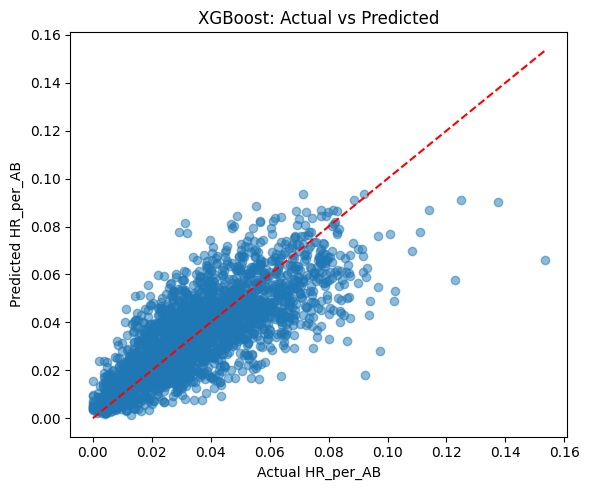

In [58]:
# Scatter plot: XGBoost predictions vs actual
plt.figure(figsize=(6, 5))
plt.scatter(y_val, y_pred, alpha=0.5)
plt.xlabel('Actual HR_per_AB')
plt.ylabel('Predicted HR_per_AB')
plt.title('XGBoost: Actual vs Predicted')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.tight_layout()
plt.show()

# RandomForestRegressor

In [59]:
# RandomForestRegressor comparison
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)
rf_mse = mean_squared_error(y_val, rf_pred)
rf_r2 = r2_score(y_val, rf_pred)

print("Random Forest Model Results:")
print(f"Mean Squared Error: {rf_mse:.6f}")
print(f"R² Score: {rf_r2:.3f}")

Random Forest Model Results:
Mean Squared Error: 0.000172
R² Score: 0.607


# Scatter plot: Random Forest predictions vs actual

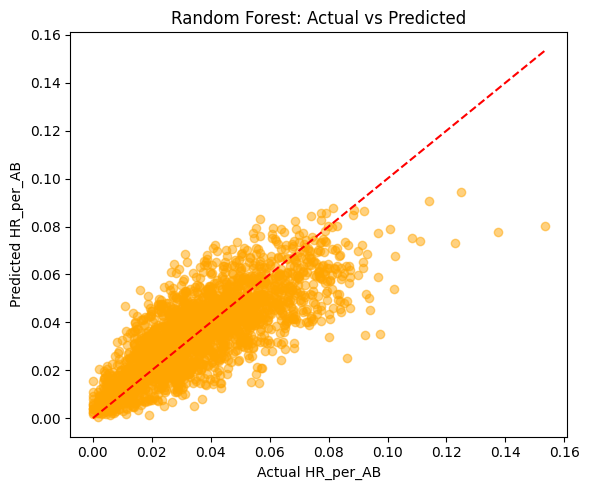

In [60]:
# Scatter plot: Random Forest predictions vs actual
plt.figure(figsize=(6, 5))
plt.scatter(y_val, rf_pred, alpha=0.5, color='orange')
plt.xlabel('Actual HR_per_AB')
plt.ylabel('Predicted HR_per_AB')
plt.title('Random Forest: Actual vs Predicted')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.tight_layout()
plt.show()

# Distribution comparison: training vs validation for each feature

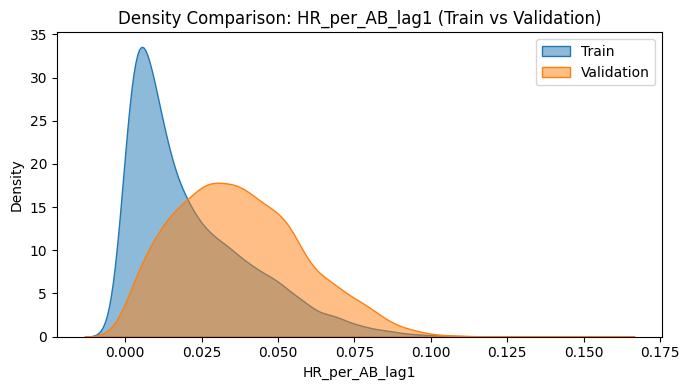

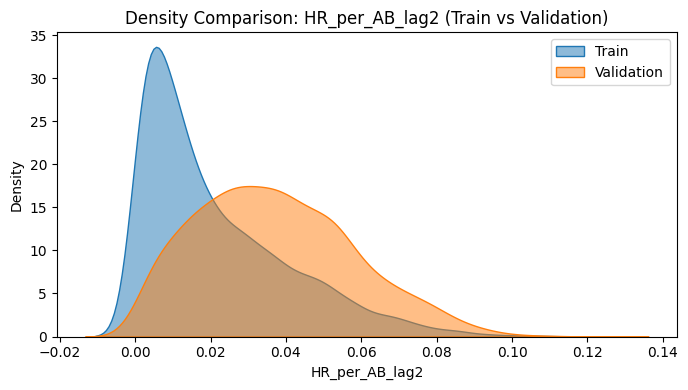

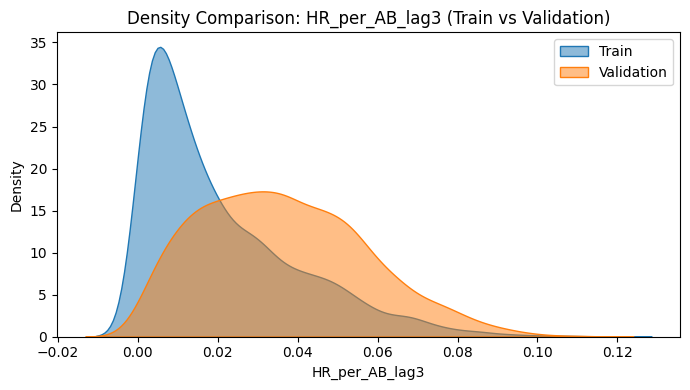

In [61]:
for col in feature_cols:
    plt.figure(figsize=(7, 4))
    sns.kdeplot(train_df[col], label='Train', fill=True, alpha=0.5)
    sns.kdeplot(val_df[col], label='Validation', fill=True, alpha=0.5)
    plt.title(f'Density Comparison: {col} (Train vs Validation)')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()